# How do online chess players lose games?
## Exploratory data analysis of Lichess games

This project explores how online chess games end and wheter the way games are lost changes with player rating.

This analysis is based on a public Lichess dataset and focuses on rated games only

## Project objective

The goal of this project is to analyze how online chess games are lost and whether the way of losing depends on player rating.

Main research question:
- Doest the way a chess game ends depend on player skill level?

Sub-questions explored in this notebook:
- How are games most commonly decided?
- Do stronger players resign more often than they get checkmated?
- Does timeout frequency change with rating?

## Imports and notebook setup

The following libraries are used for data manipulation and visualization. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

## Data loading

The dataset contains over 20,000 chess games collected from Lichess.

At this stage, the data is loaded and inspected to understand its structure, including available features, data types, and potential issues such as missing values.

In [3]:
df = pd.read_csv("games.csv")

In [4]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [6]:
df.columns.tolist()

['id',
 'rated',
 'created_at',
 'last_move_at',
 'turns',
 'victory_status',
 'winner',
 'increment_code',
 'white_id',
 'white_rating',
 'black_id',
 'black_rating',
 'moves',
 'opening_eco',
 'opening_name',
 'opening_ply']

### Dataset overview

The dataset contains over 20,000 chess games with various features descriing each match.

For the purpose of this analysis, the following key variables are used:
- "victory_status" and "winner" - to identyfy how games end
- "white_rating" and "black_rating" - to measure player skill
- "turns" - to represent game length
- "rated" - to distinguish competititve games
- "opening_eco" - to describe opening choices

There are no missing values in the key columns used for this analysis.

Only a subset of these variables is used in this analysis.

In [7]:
df[["victory_status", "white_rating", "black_rating", "rated", "turns"]].isnull().sum()

victory_status    0
white_rating      0
black_rating      0
rated             0
turns             0
dtype: int64

In [8]:
df["rated"].value_counts(normalize=True)*100

rated
True     80.54143
False    19.45857
Name: proportion, dtype: float64

## Data cleaning and preparation

To ensure meaningful and consisten analysis, several preprocessing steps were applied:

- Only rated games were selected to focus on competitive play and reduce noise from casual matches.
- Draws were excluded from the main outcome analysis to focus on decisive results (resignation, checkmate, timeout).
- A new variable "avg_rating" was created as the average of both players' ratings to represent overall game skills level.
- Games were grouped into rating categories to allow comparison across skill levels.
- The value "outoftime" was renamed to "timeout" for improved readability.

Missing values were checked only for variables used in the analysis, and no missing values were found. 

These steps ensure that the dataset is clean, consisten, and suitable for further analysis.

In [9]:
df_clean = df[df["rated"]==True].copy()

df_clean["victory_status"] = df_clean["victory_status"].replace({"outoftime": "timeout"
                                                                })

df_clean.shape

(16155, 16)

In [10]:
main_statuses = ["resign", "mate", "timeout"]
df_main = df_clean[df_clean["victory_status"].isin(main_statuses)].copy()
df_main["victory_status"].value_counts(normalize=True) * 100

victory_status
resign     57.961742
mate       33.255784
timeout     8.782474
Name: proportion, dtype: float64

In [11]:
df_main["avg_rating"] = (df_main["white_rating"] + df_main["black_rating"])/2

In [12]:
bins = [0,1200,1600,2000, np.inf]
labels = ["<1200", "1200-1599", "1600-1999", "2000+"]

df_main["rating_group"] = pd.cut(
    df_main['avg_rating'],
    bins=bins,
    labels=labels,
    right=False
)



In [13]:
df_main["rating_group"].value_counts().sort_index()

rating_group
<1200         908
1200-1599    7431
1600-1999    5991
2000+        1144
Name: count, dtype: int64

## Research Question 1
### How do rated games most commonly end?

The first step is to examine the overall distribution of game outcomes in rated games.
This provides context for the rest of the analysis.

This provides a complete overview of how games typically end. In the next steps, draws are excluded to focus on decisive outcomes (resignation, checkmate, timeout).

In [14]:
df_clean["victory_status"].value_counts()

victory_status
resign     8969
mate       5146
timeout    1359
draw        681
Name: count, dtype: int64

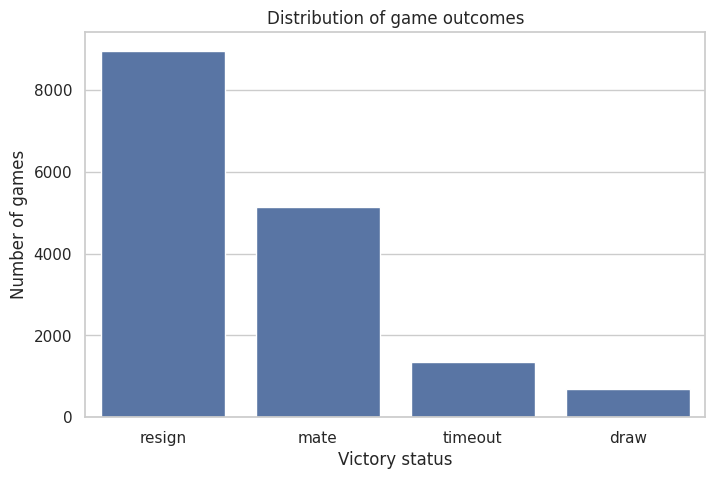

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="victory_status",
    order=df_clean["victory_status"].value_counts().index
)

plt.title("Distribution of game outcomes")
plt.xlabel("Victory status")
plt.ylabel("Number of games")

plt.show()

### Interpretation

Resignation is the most common way games end, significally more frequent than checkmate or timeout.
This suggests that many games are decided before checkmate occurs, as players tend to resign once a losing position becomes clear.
Checkmate remains relatively common, while timeout represents a smaller portion of outcomes.
Draws are present but form a minority of games, which justifies focusing further analysis on decisive outcomes.

## Research Question 2
### Does game outcome depend on player rating?

To explore wheter player skill influences how games are lost, decisive outcomes (resignation, checkmate, timeout) are compared across different rating groups.

In [16]:
rating_vs_status = pd.crosstab(
    df_main["rating_group"],
    df_main["victory_status"],
    normalize="index"
) *100



In [17]:
rating_vs_status.round(2)

victory_status,mate,resign,timeout
rating_group,,,
<1200,41.52,48.02,10.46
1200-1599,39.20,53.18,7.62
1600-1999,27.84,62.34,9.81
2000+,16.43,73.95,9.62


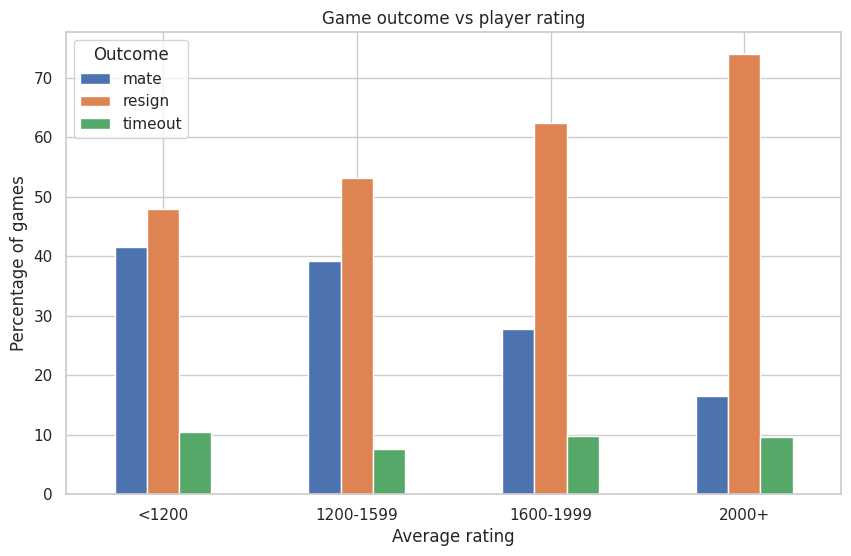

In [20]:
rating_vs_status.plot(kind="bar", figsize=(10, 6))

plt.title("Game outcome vs player rating")
plt.xlabel("Average rating")
plt.ylabel("Percentage of games")
plt.xticks(rotation=0)

plt.legend(title="Outcome")

plt.show()

### Interpretation

As player rating increases, the proportion of games ending in resignation rises significantly, while the proportion of checkmates decreases.

This suggest that stronger players are more likely to recognize losing positions and resign instead of playing until checkmate.

In contrast, lower-rated players tend to continue playing in losing positions, resulting in a higher frequency of checkmates.

Timeout frequency appears relatively stable across rating groups and does not show strong dependency on player skill level.